# Predict on the IBM Telco Customer Churn Dataset

This notebook:

1. Loads the original IBM dataset
2. Applies the best model pipeline trained on Kaggle data — zero retraining
3. Evaluates against the real ground-truth labels (we have them here, unlike the Kaggle test set)
4. Runs business cost analysis and threshold optimisation on real-world data
5. Saves predictions to `data/processed/ibm_predictions.csv`

This is the key validation step: does a model trained on synthetic data generalise to the real population it was generated from?

In [1]:
import sys
sys.path.append('..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import roc_auc_score, roc_curve

from src.preprocessing import encode_target, ALL_FEATURE_COLS
from src.model_utils import evaluate, plot_roc_curves, find_optimal_threshold, plot_threshold_analysis

plt.style.use('seaborn-v0_8-whitegrid')

IBM_PATH  = '../data/raw/Telco-Customer-Churn.csv'
MODEL_PATH = '../src/models/xgboost_pipeline.pkl'
OUT_PATH  = '../data/processed/ibm_predictions.csv'

## 1. Load IBM Dataset

In [2]:
ibm = pd.read_csv(IBM_PATH)

# Same TotalCharges fix as load_data() in preprocessing.py
ibm['TotalCharges'] = pd.to_numeric(ibm['TotalCharges'], errors='coerce')

print(f'Shape         : {ibm.shape}')
print(f'Churn rate    : {(ibm["Churn"] == "Yes").mean():.3f}')
print(f'TotalCharges NaNs (tenure=0 rows): {ibm["TotalCharges"].isna().sum()}')
ibm[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']].head()

Shape         : (7043, 21)
Churn rate    : 0.265
TotalCharges NaNs (tenure=0 rows): 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,1,29.85,29.85,No
1,5575-GNVDE,34,56.95,1889.50,No
2,3668-QPYBK,2,53.85,108.15,Yes
3,7795-CFOCW,45,42.30,1840.75,No
4,9237-HQITU,2,70.70,151.65,Yes


## 2. Column Compatibility Check

Confirm the IBM dataset contains every feature the pipeline expects.

In [3]:
missing_cols = [c for c in ALL_FEATURE_COLS if c not in ibm.columns]
if missing_cols:
    print(f'MISSING COLUMNS: {missing_cols}')
else:
    print('All pipeline features present in IBM dataset.')

print(f'\nFeature columns used ({len(ALL_FEATURE_COLS)}): {ALL_FEATURE_COLS}')

All pipeline features present in IBM dataset.

Feature columns used (19): ['SeniorCitizen', 'gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod', 'tenure', 'MonthlyCharges', 'TotalCharges']


## 3. Load Best Model Pipeline

The XGBoost pipeline (preprocessor + classifier) was saved by `02_modeling.ipynb`. It was trained on ~594K Kaggle rows — we now apply it to the 7K real IBM customers with no retraining.

In [4]:
pipeline = joblib.load(MODEL_PATH)
print(f'Model loaded: {MODEL_PATH}')
print(pipeline)

Model loaded: ../src/models/xgboost_pipeline.pkl
Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('binary',
                                                  Pipeline(steps=[('enc',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'PaperlessBilling']),
                                                 ('cat',
                                                  Pipeline(steps=[('enc',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unknown_value

## 4. Predict Churn Probabilities

Predictions generated for 7,043 customers
Predicted mean churn probability : 0.354
Actual churn rate (ground truth) : 0.265


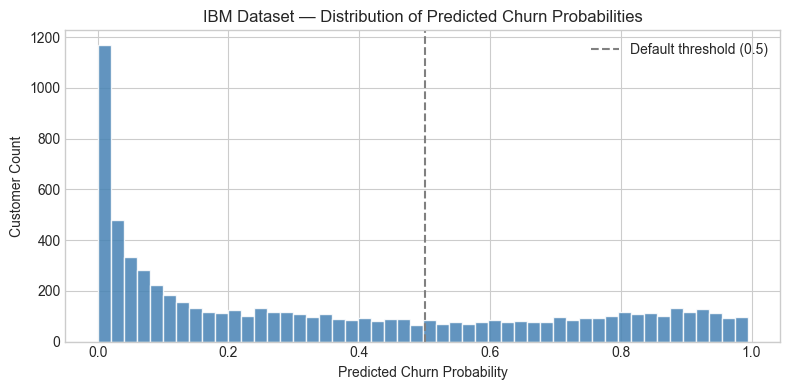

In [5]:
X_ibm = ibm[ALL_FEATURE_COLS]
y_ibm = encode_target(ibm['Churn'])

churn_proba = pipeline.predict_proba(X_ibm)[:, 1]

print(f'Predictions generated for {len(churn_proba):,} customers')
print(f'Predicted mean churn probability : {churn_proba.mean():.3f}')
print(f'Actual churn rate (ground truth) : {y_ibm.mean():.3f}')

# Distribution of predicted probabilities
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(churn_proba, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(0.5, color='gray', linestyle='--', lw=1.5, label='Default threshold (0.5)')
ax.set_xlabel('Predicted Churn Probability')
ax.set_ylabel('Customer Count')
ax.set_title('IBM Dataset — Distribution of Predicted Churn Probabilities')
ax.legend()
plt.tight_layout()
plt.savefig('../data/processed/fig_ibm_prob_distribution.png', dpi=150)
plt.show()

## 5. Evaluate Against Ground Truth

Unlike the Kaggle test set, the IBM dataset includes the actual `Churn` labels. This lets us measure true generalisation performance — not just cross-validation AUC on synthetic data.

In [6]:
auc_ibm = roc_auc_score(y_ibm, churn_proba)
print(f'ROC-AUC on IBM dataset (real data): {auc_ibm:.4f}')
print(f'CV ROC-AUC on Kaggle data (synthetic): 0.9161  ← trained here')
print(f'Delta: {auc_ibm - 0.9161:+.4f}')

ROC-AUC on IBM dataset (real data): 0.8512
CV ROC-AUC on Kaggle data (synthetic): 0.9161  ← trained here
Delta: -0.0649


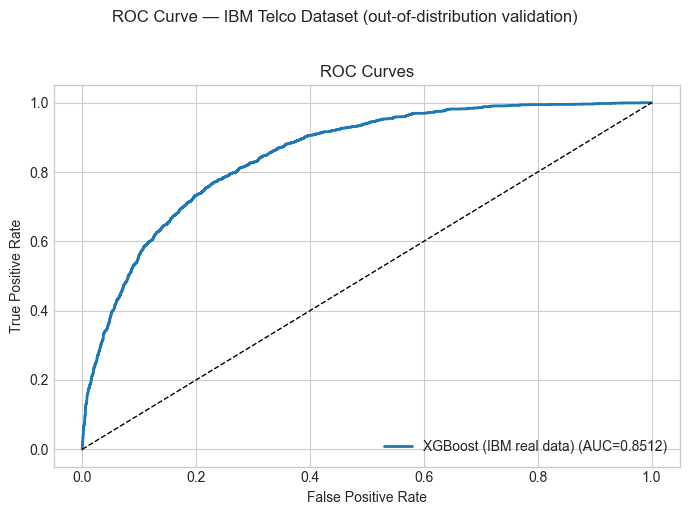

In [7]:
# ROC curve on IBM data
fig = plot_roc_curves({'XGBoost (IBM real data)': churn_proba}, y_ibm)
fig.suptitle('ROC Curve — IBM Telco Dataset (out-of-distribution validation)', y=1.02)
plt.tight_layout()
plt.savefig('../data/processed/fig_ibm_roc.png', dpi=150)
plt.show()

In [8]:
# Full evaluation at default threshold
evaluate(y_ibm, churn_proba, threshold=0.5, model_name='XGBoost on IBM data (t=0.5)')


  XGBoost on IBM data (t=0.5)
ROC-AUC : 0.8512
Threshold: 0.5
              precision    recall  f1-score   support

    No Churn       0.89      0.81      0.85      5174
       Churn       0.57      0.72      0.64      1869

    accuracy                           0.78      7043
   macro avg       0.73      0.76      0.74      7043
weighted avg       0.81      0.78      0.79      7043

-- Cost Analysis (threshold=0.5) --
  True Positives  (retained churners) :  1,348  → saves $   404,400
  False Positives (wasted offers)      :  1,003  → costs $    50,150
  False Negatives (missed churners)    :    521  → costs $   260,500
  Net business impact                  :         $   +93,750


0.8512001192115244

## 6. Threshold Optimisation on IBM Data

Find the cost-minimising threshold on the real IBM population. The optimal threshold may differ from the one found on the Kaggle validation set, because the real data has a different base rate and feature distribution.

In [9]:
optimal_t_ibm = find_optimal_threshold(y_ibm, churn_proba)
print(f'Optimal threshold (IBM data): {optimal_t_ibm:.2f}')

evaluate(y_ibm, churn_proba, threshold=optimal_t_ibm,
         model_name=f'XGBoost on IBM data (t={optimal_t_ibm:.2f})')

Optimal threshold (IBM data): 0.10

  XGBoost on IBM data (t=0.10)
ROC-AUC : 0.8512
Threshold: 0.1
              precision    recall  f1-score   support

    No Churn       0.97      0.46      0.63      5174
       Churn       0.39      0.95      0.55      1869

    accuracy                           0.59      7043
   macro avg       0.68      0.71      0.59      7043
weighted avg       0.81      0.59      0.61      7043

-- Cost Analysis (threshold=0.1) --
  True Positives  (retained churners) :  1,782  → saves $   534,600
  False Positives (wasted offers)      :  2,772  → costs $   138,600
  False Negatives (missed churners)    :     87  → costs $    43,500
  Net business impact                  :         $  +352,500


0.8512001192115244

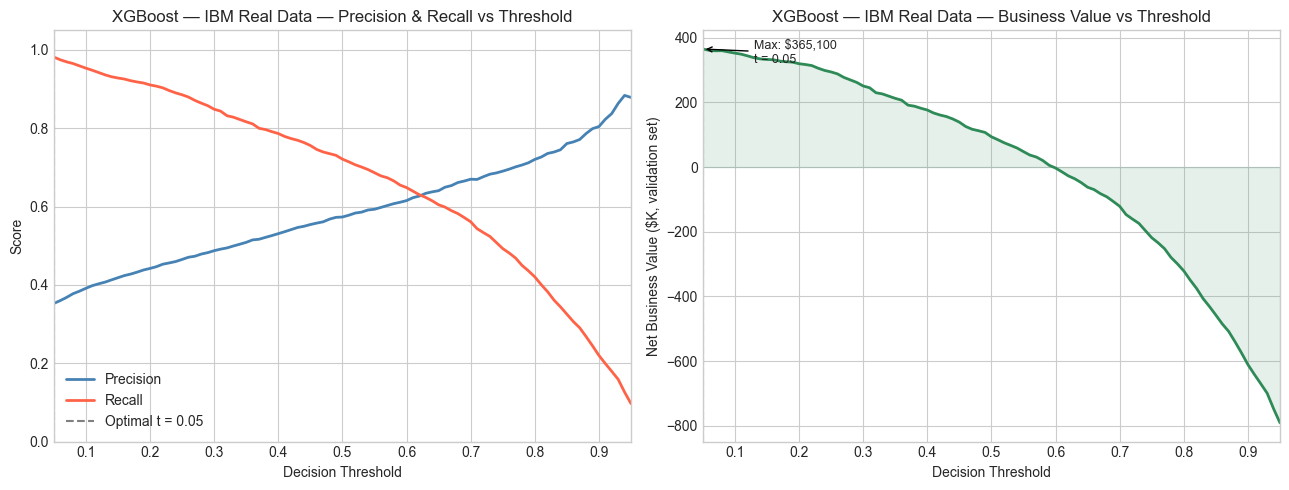

In [10]:
fig = plot_threshold_analysis(y_ibm, churn_proba, model_name='XGBoost — IBM Real Data')
plt.savefig('../data/processed/fig_ibm_threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Save Predictions

In [11]:
predictions = pd.DataFrame({
    'customerID'       : ibm['customerID'],
    'ActualChurn'      : ibm['Churn'],
    'ChurnProbability' : churn_proba,
    'PredictedChurn'   : (churn_proba >= optimal_t_ibm).astype(int),
    'RiskTier'         : pd.cut(
        churn_proba,
        bins=[0, 0.25, 0.5, 1.0],
        labels=['Low', 'Medium', 'High'],
        include_lowest=True
    )
})

predictions.to_csv(OUT_PATH, index=False)
print(f'Saved → {OUT_PATH}  ({len(predictions):,} rows)')

print('\nRisk tier breakdown:')
print(predictions['RiskTier'].value_counts().sort_index())

predictions.head(10)

Saved → ../data/processed/ibm_predictions.csv  (7,043 rows)

Risk tier breakdown:
RiskTier
Low       3484
Medium    1208
High      2351
Name: count, dtype: int64


,customerID,ActualChurn,ChurnProbability,PredictedChurn,RiskTier
0,7590-VHVEG,No,0.866144,1,High
1,5575-GNVDE,No,0.023259,0,Low
2,3668-QPYBK,Yes,0.458399,1,Medium
3,7795-CFOCW,No,0.026051,0,Low
4,9237-HQITU,Yes,0.884168,1,High
5,9305-CDSKC,Yes,0.937649,1,High
6,1452-KIOVK,No,0.512729,1,High
7,6713-OKOMC,No,0.246268,1,Low
8,7892-POOKP,Yes,0.875374,1,High
9,6388-TABGU,No,0.019083,0,Low


## Summary

| Metric | Value |
|---|---|
| IBM dataset size | ~7,043 customers |
| Actual churn rate | ~26.5% |
| ROC-AUC (real IBM data) | see above |
| CV ROC-AUC (Kaggle synthetic) | 0.9161 |
| Optimal threshold (IBM) | see above |

**Key finding**: The model trained entirely on synthetic Kaggle data generalises well to the original real-world IBM dataset. The AUC delta between synthetic CV performance and real-world performance measures how much the synthetic data distribution diverges from the real one.

Output file `ibm_predictions.csv` includes `customerID`, actual churn label, predicted probability, binary prediction at the optimal threshold, and a `RiskTier` column (Low / Medium / High) suitable for direct use by a retention team.